In [43]:
import importlib
import sys
from pathlib import Path
SCRIPTS = Path().resolve() / "libraries"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
import post_mcmc
import numpy as np
importlib.reload(post_mcmc)
from gala.coordinates import GreatCircleICRSFrame
import astropy.coordinates as coord
from astropy import units as u
import matplotlib.pyplot as plt
from post_mcmc import plot_form
import copy
import pandas as pd
from scipy import stats
import stream_functions as stream_funcs
import streamTutorial as st
import corner
from astropy import table
from scipy import stats

In [44]:
def get_mem_path(directory):
    import os
    files = os.listdir(directory)
    for file in files:
        if ('0.5%_mem' in file or '50%_mem' in file) and file.endswith('.fits'):
            return os.path.join(directory, file)

mem_path = get_mem_path('/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/runs/M92-I21_260119_generic_test_locTrue/')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)

In [45]:
import galstreams
mwsts = galstreams.MWStreams(verbose=False, implement_Off=True)
galstream_=mwsts.get('M92-I21')
fr = galstream_.stream_frame

Initializing galstreams library from master_log... 


In [5]:
desi_data = post_mcmc.load_desi_data(desi_path = '/Users/nasserm/Documents/vscode/data/old_photometry_loa_cleaned_051125.fits', fr=fr, local=True, distance_path = '/Users/nasserm/Documents/vscode/data/rvsdistnn-loa-241126.fits')


desi_data['VGSR'] = stream_funcs.vhel_to_vgsr(
    np.array(desi_data['TARGET_RA']) * u.deg,
    np.array(desi_data['TARGET_DEC']) * u.deg,
    np.array(desi_data['VRAD']) * (u.km / u.s),
).value



desi_data['phi1'], desi_data['phi2'] = stream_funcs.ra_dec_to_phi1_phi2(
    fr,
    np.array(desi_data['TARGET_RA']) * u.deg,
    np.array(desi_data['TARGET_DEC']) * u.deg,
)

RVS distances added


In [48]:
desi_data

,TARGET_RA,TARGET_DEC,FEH,FEH_ERR,LOGG,TARGETID,VRAD,PRIMARY,TEFF,VRAD_ERR,...,dist_mod_err,FLUX_Z,FLUX_R,FLUX_G,EBV,dist_mod_err_right,dist_mod_right,VGSR,phi1,phi2
0,25.159859,32.408638,-0.780013,0.013224,4.598761,39628530270601815,-20.723753,True,6235.724628,0.968186,...,0.080150,172.413254,157.846954,112.274818,0.044945,0.080150,12.672941,119.380481,85.871030,81.039918
1,24.955285,32.197888,-0.706914,0.039468,4.764995,1152921504619435900,-57.827379,True,3861.818815,1.496343,...,NaN,21.934380,8.946404,2.453177,0.049809,NaN,NaN,82.295318,86.356258,80.778312
2,24.931222,32.126668,-0.954418,0.011138,4.082105,39628525149358093,-2.709871,True,6288.958057,0.925257,...,0.123923,534.231201,503.059357,372.109680,0.049990,0.123923,12.154305,137.313309,86.648106,80.720985
3,25.008393,32.097220,0.313138,0.035541,4.821189,1152921504619435964,-39.114523,True,3326.995536,1.479810,...,NaN,30.564667,4.929417,1.287760,0.048915,NaN,NaN,100.663011,87.031221,80.757572
4,24.851085,32.140174,0.188343,0.037153,4.470738,1152921504619435903,-56.841151,True,3429.081292,1.111625,...,NaN,55.799023,10.561476,2.834843,0.051363,NaN,NaN,83.399512,86.340119,80.672937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9770103,252.249961,33.326425,-0.821993,0.086836,4.311372,39632946780438706,-33.121636,True,3902.506993,2.917980,...,NaN,15.384500,6.443040,1.869596,0.030400,NaN,NaN,134.311016,-1.351012,-11.280437
9770104,250.961177,33.295010,-1.470989,0.025182,4.145432,39632946759470577,-55.904753,True,6162.970072,1.325791,...,0.131673,112.015099,104.504715,77.734718,0.026773,0.136928,13.556334,108.713550,-2.292611,-11.837206
9770105,250.961177,33.295010,-1.470989,0.025182,4.145432,39632946759470577,-55.904753,True,6162.970072,1.325791,...,0.131673,112.015099,104.504715,77.734718,0.026773,0.131673,13.543329,108.713550,-2.292611,-11.837206
9770106,251.211554,33.305631,-1.715234,0.036413,4.578232,39632946763663809,-90.549281,True,6078.954946,1.945222,...,0.094742,55.116001,49.928703,35.717365,0.030453,0.153665,13.351147,74.627065,-2.111063,-11.726213


In [46]:
importlib.reload(post_mcmc)
min_dist = np.min(galstream_.track.distance.value)
stream_ = post_mcmc.StreamMembers(min_dist=min_dist, stream_data=stream_data, desi_data = None, stream_run_directory=stream_run_directory, fr=fr, withBHB=False, withRRL=False)

Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


In [7]:
stream_.stream_data

TARGET_RA,TARGET_DEC,FEH,FEH_ERR,LOGG,TARGETID,VRAD,PRIMARY,TEFF,VRAD_ERR,PARALLAX_ERROR,PMDEC_ERROR,PHOT_BP_MEAN_FLUX,PMRA_ERROR,PMRA,PARALLAX,PMDEC,PMRA_PMDEC_CORR,SOURCE_ID,PHOT_RP_MEAN_FLUX,dist_mod,dist_mod_err,FLUX_Z,FLUX_R,FLUX_G,EBV,dist_mod_err_right,dist_mod_right,VGSR,phi1,phi2,stream_prob,stream_prob_em,stream_prob_ep
float64,float64,float64,float64,float64,int64,float64,bool,float64,float64,float32,float64,float64,float64,float64,float64,float64,float32,int64,float64,float64,float64,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64
254.91769639798736,40.91418873899564,-2.0376915933185087,0.03287183351043209,2.631290214281189,2305843019305190658,-136.18525830333635,True,5383.169546714687,1.5168714588918328,0.032445647,0.04698717957691771,2764.804675643085,0.042518178362387776,-4.486792643104799,0.08212088086336453,-1.6994102896814995,0.13506737,1354500232663152000,3838.730755678368,15.310407724683191,0.3461313843727112,388.55838,307.88583,186.63765,0.025320265,0.3899444684850667,15.293366977227034,48.868178748757856,-3.6179978111551523,-1.5321755676124968,0.9582076308539051,0.9388960388773981,0.9693597604163949
269.3082301613415,39.84665556686474,-2.2666913741500663,0.18201715150401945,3.9101133929546528,39633073402284331,-109.7551419324412,True,6377.00325994374,6.797522558285879,0.13949682,0.19058248308401038,354.59258115369954,0.15273026195949116,-5.384418047889635,0.1921327607848907,0.846035201421206,-0.017771376,4611419180699502208,399.03671846098626,15.341083526611328,0.39117881655693054,36.972088,34.71421,26.253368,0.039644845,0.40121397665680575,15.405641054402931,98.71662239221183,7.089481577245012,-4.116671993522934,0.7522598504172453,0.5917161464782782,0.8544790483535907
262.0200817894791,49.900405771608284,-2.459787539332252,0.11985201498517165,4.375081229112557,39633248950685528,-120.3434678601684,True,6223.715495387476,5.413778956850058,0.13663566,0.1722062127473651,331.9465017846077,0.15369762475457732,-5.546679794636727,0.12168363430070271,0.7465468683313068,0.07682078,1366704738716424576,349.1560654076552,14.04384048391412,0.3279534876346588,35.286083,32.278812,23.731283,0.0364473,0.5788960853447498,13.950266365789382,85.60261568787988,2.9315152693719737,6.382366026959496,0.9866219065535194,0.9827837113208021,0.9892105536423531
252.9477748479723,43.67760662324862,-1.9346206824528012,0.04486348207780722,3.1925231009103436,39633145431066992,-150.94809254525822,True,5443.1186383075365,1.8507375716785295,0.05468661,0.08371694815591553,1272.8104679937496,0.06876459592072173,-3.603395333323081,0.04445003642633753,-2.0400876331547924,0.0988768,1358970602128182528,1741.6120037332491,15.57248306274414,0.22152799367904663,182.35246,141.77213,86.210655,0.014373245,0.259114533662796,15.733080863952637,34.12919068294852,-4.383620170040693,1.4963684409915594,0.7936316924865374,0.696323259594982,0.8464171396022752
251.95193874248764,37.31345851285586,-3.0897221257614516,0.1599920370662306,5.2975654128897425,39633025813712470,-169.43793293058255,True,6664.105985166213,8.793058562889929,0.15952006,0.1990869731471212,278.6709401993977,0.1580671562159121,-2.840680989140461,-0.29151120014194154,-3.3410331106332114,0.15554808,1351462866151388416,293.7497558642513,14.551121053215045,0.17774510383605957,27.50111,25.811272,20.03952,0.029548775,0.09303519874811172,14.69237232208252,4.373450242064109,-6.724370160164354,-4.470500262218143,0.9748844469605518,0.9533807078095844,0.9841853788263117
254.81457405505932,44.99498453932379,-2.901350399393473,0.2633072092067763,4.716079214955929,39633167090452336,-151.28894728206822,True,6580.628169907738,9.326592337313498,0.16815196,0.22699306534476127,271.1694488623419,0.19265622592997034,-4.617891286750039,0.19005735793000406,-1.5926505153887724,0.29389912,1359149551941417216,258.4634457040582,14.975890159606934,0.234405517578125,25.752424,25.228931,19.878126,0.017573053,0.2637261152267456,15.07694149017334,38.72434226352763,-2.774204975

No orbit results found, skipping orbit track plotting
/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/libraries/post_mcmc.py:2696: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



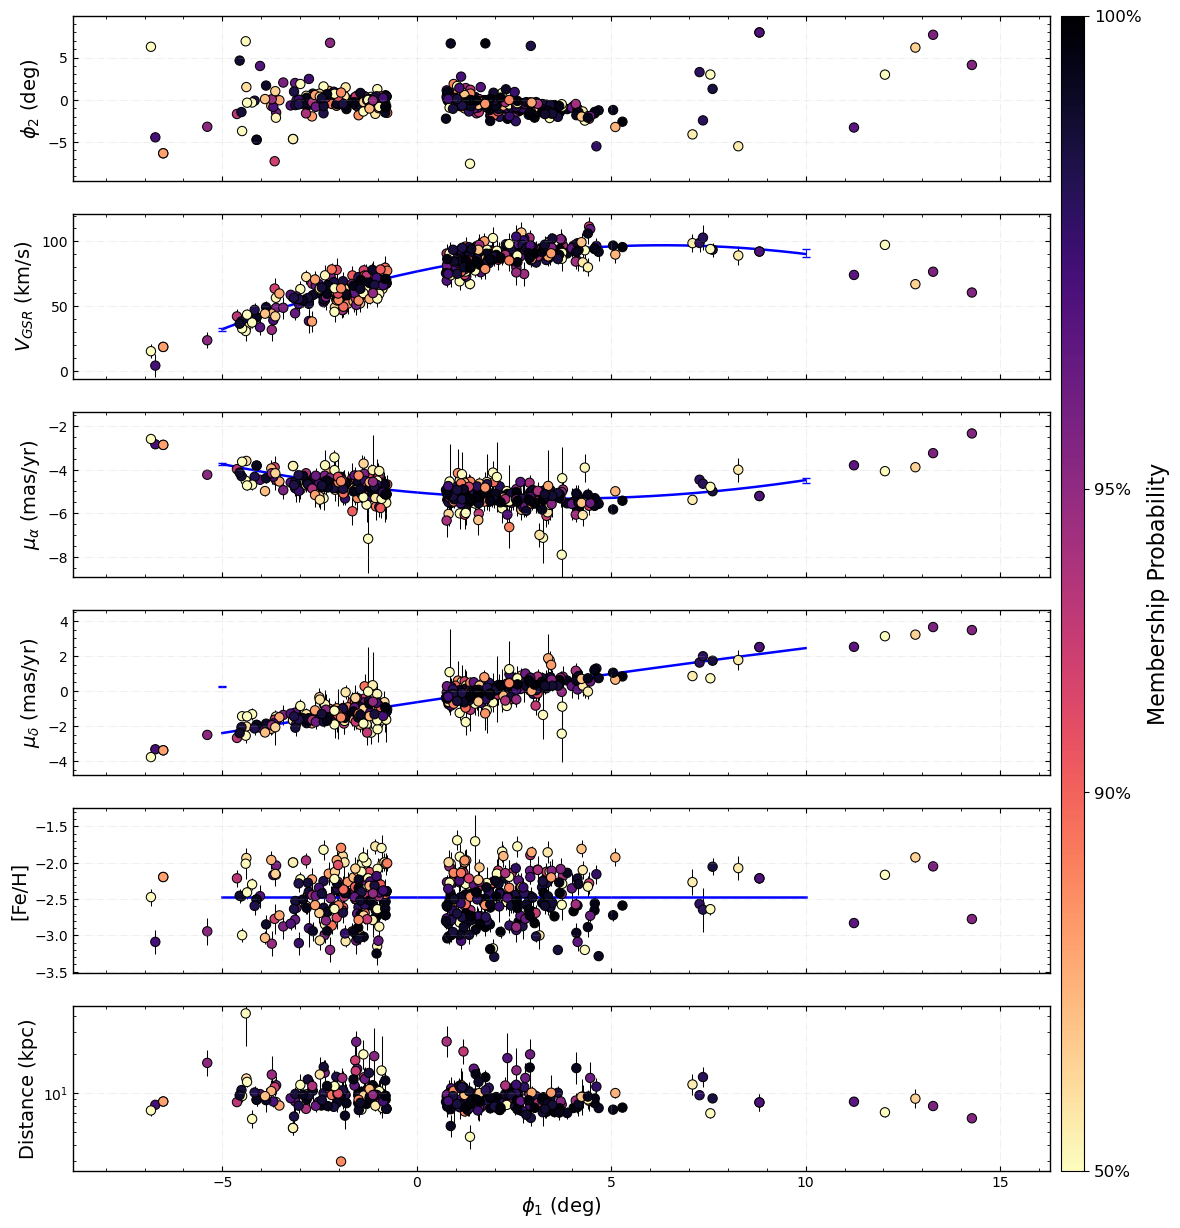

In [47]:
fig,ax = stream_.vis_6_panel(addBackground=False, save_fig=False, show_pm_dispersion=False, show_vgsr_dispersion=False, dist_mod_panel=True, min_prob=0.5, residual=False, show_feh_dispersion=False)

# Look at our posterior distributions

In [37]:
def flatter(obj):
    """
    Flattens mcmc output
    """
    for x in obj:
        if isinstance(x, (list, tuple)):
            yield from flatter(x)
        else:
            yield x
extended_meds = list(flatter(stream_.nested_dict['meds']))

In [38]:
extended_meds

[0.026547314805376247,
 32.46993839866592,
 89.68859990901296,
 90.34431610844132,
 0.6726921334588184,
 -2.4735423146262154,
 -0.5058853116187572,
 -3.7479492697131835,
 -5.301485779482675,
 -4.480268549450065,
 -0.628329520089441,
 -2.4134947101838913,
 0.17933275433202323,
 2.4451263705065918,
 -0.6780901436144693,
 28.968200723837562,
 2.0378163470963413,
 -1.2827058133032214,
 -0.17063984770780102,
 10.109730796096484,
 0.7628428831750873,
 -1.4942564522370607,
 0.4952761774880027]

Print indicies for each posterior dimension

In [36]:
for i, name in enumerate(stream_.nested_dict['expanded_param_labels']):
    print(i, name)

0 pstream
1 vgsr1
2 vgsr2
3 vgsr3
4 lsigvgsr
5 feh1
6 lsigfeh
7 pmra1
8 pmra2
9 pmra3
10 lsigpmra
11 pmdec1
12 pmdec2
13 pmdec3
14 lsigpmdec
15 bv
16 lsigbv
17 bfeh
18 lsigbfeh
19 bpmra
20 lsigbpmra
21 bpmdec
22 lsigbpmdec


``` 'meds' ``` refers to median posterior values from the MCMC

In [10]:
pick = np.array([2, 4, 7, 8, 12, 5, 6]) # the posterior dimensions we'll vis

labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]
chain = np.vstack([stream_.mcmc_dict['flatchain'][:, p] for p in pick])
mu = {l: extended_meds[stream_.mcmc_dict['extended_param_labels'].index(l)] for l in labels}
std = {l: stream_.mcmc_dict['flatchain'][:, stream_.mcmc_dict['extended_param_labels'].index(l)].std() for l in labels}

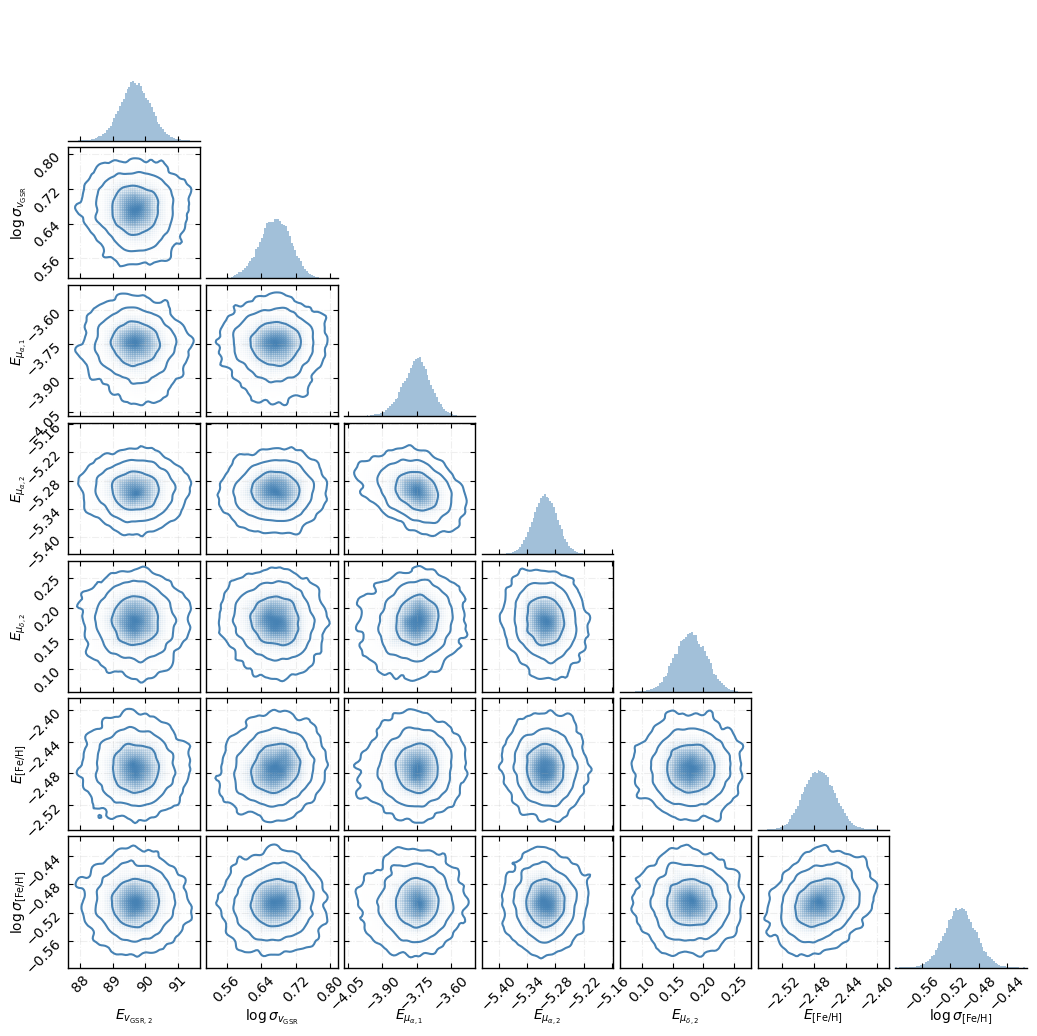

In [11]:
st.set_presentation(False)

def latex_label(lbl):
    if lbl.startswith("vgsr"):
        return rf"$E_{{v_{{\text{{GSR}}, {lbl[4:]}}}}}$"
    if lbl.startswith("pmra"):
        return rf"$E_{{\mu_{{\alpha, {lbl[4:]}}}}}$"
    if lbl.startswith("pmdec"):
        return rf"$E_{{\mu_{{\delta, {lbl[5:]}}}}}$"
    if lbl.startswith("lsigvgsr"):
        return rf"$\log \sigma_{{v_{{\text{{GSR}} {lbl[8:]}}}}}$"
    if lbl.startswith("lsigfeh"):
        return rf"$\log \sigma_{{[\text{{Fe/H}}] {lbl[7:]}}}$"
    if lbl == "feh1":
        return r"$E_{[\text{Fe/H}]}$"
    if lbl == "pstream":
        return r"$f_s$"
    return lbl

corner_labels = [latex_label(lbl) for lbl in labels]
fig = corner.corner(chain.T, color='steelblue', labels=corner_labels, smooth=1.5, bins=70, levels=[0.68, 0.95, .997], plot_datapoints=False,
                    hist_kwargs={"density": True, "color": "steelblue", "histtype": "stepfilled", "alpha": 0.5},
                    )
fig.set_size_inches(1.5 * chain.T.shape[1], 1.5 * chain.T.shape[1])

for ax in fig.axes:
    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    ax.set_ylim(ylim[0] * 1, ylim[1] * 1)
    ax.set_xlim(xlim[0] * 1, xlim[1] * 1)
    ax.tick_params(which="minor", color='1', length=0)

for ax in np.diag(np.array(fig.axes).reshape(chain.T.shape[1], chain.T.shape[1])):
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)



# Single Posterior Realization

In [12]:
phi1_spline_points = stream_.spline_points_dict['phi1_spline_points']

In [13]:
vgsr_func = lambda phi1_arr, meds: stream_funcs.apply_spline(phi1_arr, phi1_spline_points, meds)

def _spline_coeffs_from_draw(draw, prefix, n_spline_points):
    """Collect spline coefficients like prefix1..prefixN from one MCMC draw."""
    coeff_keys = [f"{prefix}{i}" for i in range(1, n_spline_points + 1)]
    missing = [k for k in coeff_keys if k not in draw]
    if missing:
        raise KeyError(
            f"Missing spline coefficients for '{prefix}': {missing}. "
            f"Available keys include: {sorted(draw.keys())[:10]}..."
        )
    return np.array([draw[k] for k in coeff_keys], dtype=float)

def draw_stream(stream_idx, stream_df, n_samples):
    """Draw intrinsic stream stars and `n_samples` noisy realizations.

    Args:
        stream_idx: Indices into `stream_.mcmc_dict['extended_param_labels']`.
        stream_df: DataFrame with `phi1` and measurement-error columns.
        n_samples: Noisy draws per star.

    Returns:
        star_draw_df: Intrinsic draws (one row per star).
        error_draw_df: Noisy draws stacked row-wise.
    """
    pick = stream_idx
    stream_phi1_arr = stream_df['phi1']
    labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]

    rng = np.random.default_rng()
    flatchain = stream_.mcmc_dict['flatchain']
    extended_labels = stream_.mcmc_dict['extended_param_labels']
    label_idx = {label: extended_labels.index(label) for label in labels}
    chain_idx = rng.integers(0, flatchain.shape[0])
    theta_row = flatchain[chain_idx]

    n_spline_points = len(stream_.spline_points_dict['phi1_spline_points'])

    star = []
    for _ in stream_phi1_arr:
        draw = {label: theta_row[label_idx[label]] for label in labels}
        star.append(draw)

    star_draw = []
    final_labels = ['VGSR', 'FEH', 'PMRA', 'PMDEC', 'phi1']

    for s, phi1 in zip(star, stream_phi1_arr):
        star_properties = {}
        for labl in final_labels:
            if labl == 'VGSR':
                vgsr_coeffs = _spline_coeffs_from_draw(s, 'vgsr', n_spline_points)
                vgsr = vgsr_func(phi1, vgsr_coeffs)
                star_properties[labl] = rng.normal(vgsr, 10**s['lsigvgsr'])
            elif labl == 'PMRA':
                pmra_coeffs = _spline_coeffs_from_draw(s, 'pmra', n_spline_points)
                pmra = stream_funcs.apply_spline(phi1, stream_.spline_points_dict['phi1_spline_points'], pmra_coeffs)
                star_properties[labl] = rng.normal(pmra, 0.09)
            elif labl == 'PMDEC':
                pmdec_coeffs = _spline_coeffs_from_draw(s, 'pmdec', n_spline_points)
                pmdec = stream_funcs.apply_spline(phi1, stream_.spline_points_dict['phi1_spline_points'], pmdec_coeffs)
                star_properties[labl] = rng.normal(pmdec, 0.09)
            elif labl == 'FEH':
                star_properties[labl] = rng.normal(s['feh1'], 10**s['lsigfeh'])
            else:
                star_properties['phi1'] = phi1
        star_draw.append(star_properties)

    star_draw_df = pd.DataFrame(star_draw)

    err_labels = ['VRAD_ERR', 'FEH_ERR', 'PMRA_ERROR', 'PMDEC_ERROR']
    err_df = stream_df[err_labels]

    error_draw = {}
    for labl, err_labl in zip(final_labels, err_labels):
        mu = np.asarray(star_draw_df[labl], dtype=float)
        sigma = np.asarray(err_df[err_labl], dtype=float)
        error_draw[labl] = rng.normal(loc=mu, scale=sigma, size=(n_samples, mu.size))

    rows = []
    for i, phi1_val in enumerate(star_draw_df['phi1']):
        df = pd.DataFrame({lab: error_draw[lab][:, i] for lab in error_draw})
        df['phi1'] = phi1_val
        rows.append(df)

    error_draw_df = pd.concat(rows, ignore_index=True)

    return star_draw_df, error_draw_df

def sample_err(mu, err, N):
    return np.random.default_rng.normal(loc=mu, scale=err, size=(N, )+mu.shape)

def draw_background(background_idx, background_df, n_samples, reject_df=None):
    """Draw intrinsic background stars and `n_samples` noisy realizations (truncated-normal).

    This matches rejection-sampling from a normal constrained to [low, high],
    but is much faster by drawing directly from scipy.stats.truncnorm.
    """
    pick = background_idx
    phi1_vals = np.asarray(background_df['phi1'], dtype=float)

    # Use whichever catalogue defines the selection window
    window_df = background_df if reject_df is None else reject_df
    bounds = {
        'VGSR': (np.nanmin(window_df['VGSR']), np.nanmax(window_df['VGSR'])),
        'PMRA': (np.nanmin(window_df['PMRA']), np.nanmax(window_df['PMRA'])),
        'PMDEC': (np.nanmin(window_df['PMDEC']), np.nanmax(window_df['PMDEC'])),
        'FEH':  (np.nanmin(window_df['FEH']),  np.nanmax(window_df['FEH'])),
    }

    labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]
    rng = np.random.default_rng()
    flatchain = stream_.mcmc_dict['flatchain']
    extended_labels = stream_.mcmc_dict['extended_param_labels']
    label_idx = {label: extended_labels.index(label) for label in labels}
    theta_row = flatchain[rng.integers(0, flatchain.shape[0])]
    theta_map = {label: theta_row[label_idx[label]] for label in labels}

    n_stars = phi1_vals.size
    star_draw_df = pd.DataFrame({'phi1': phi1_vals})

    intrinsic_cfg = {
        'VGSR': ('bv', 'lsigbv'),
        'PMRA': ('bpmra', 'lsigbpmra'),
        'PMDEC': ('bpmdec', 'lsigbpmdec'),
        'FEH': ('bfeh', 'lsigbfeh'),
    }

    # Intrinsic background draws (one per star), truncated to window bounds.
    for key, (mu_key, lsig_key) in intrinsic_cfg.items():
        mu = float(theta_map[mu_key])
        sigma = float(10 ** theta_map[lsig_key])
        low, high = bounds[key]
        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError(f"Invalid intrinsic sigma for {key}: {sigma}")
        a = (low - mu) / sigma
        b = (high - mu) / sigma
        star_draw_df[key] = stats.truncnorm.rvs(a=a, b=b, loc=mu, scale=sigma, size=n_stars, random_state=rng)

    err_labels = {
        'VGSR': 'VRAD_ERR',
        'PMRA': 'PMRA_ERROR',
        'PMDEC': 'PMDEC_ERROR',
        'FEH':  'FEH_ERR',
    }
    err_df = background_df[list(err_labels.values())]

    # Measurement draws: shape (n_samples, n_stars) per quantity
    error_draw = {}
    for key, err_name in err_labels.items():
        mu = np.asarray(star_draw_df[key], dtype=float)
        sigma = np.asarray(err_df[err_name], dtype=float)
        low, high = bounds[key]
        if np.any(~np.isfinite(sigma)) or np.any(sigma <= 0):
            raise ValueError(f"Invalid measurement sigma(s) for {key}")
        a = (low - mu) / sigma
        b = (high - mu) / sigma
        error_draw[key] = stats.truncnorm.rvs(
            a=a[np.newaxis, :],
            b=b[np.newaxis, :],
            loc=mu[np.newaxis, :],
            scale=sigma[np.newaxis, :],
            size=(n_samples, n_stars),
            random_state=rng,
        )

    rows = []
    for k in range(n_samples):
        df = pd.DataFrame({key: error_draw[key][k] for key in err_labels})
        df['phi1'] = phi1_vals
        rows.append(df)

    error_draw_df = pd.concat(rows, ignore_index=True)
    return star_draw_df, error_draw_df




In [14]:
# Posterior draws → predictive catalogues
rng = np.random.default_rng(14)
chain = stream_.mcmc_dict['flatchain']
labels = stream_.mcmc_dict['extended_param_labels']
phi1_nodes = np.asarray(stream_.stream_data['phi1'], dtype=float)
phi1_knots = stream_.spline_points_dict['phi1_spline_points']

err_cols = {
    'VGSR': 'VRAD_ERR',
    'PMRA': 'PMRA_ERROR',
    'PMDEC': 'PMDEC_ERROR',
    'FEH': 'FEH_ERR',
}
stream_errors = {col: np.asarray(stream_.stream_data[col], dtype=float) for col in err_cols.values()}

In [15]:
summary_keys = ['VGSR', 'PMRA', 'PMDEC', 'FEH']
summary_labels = [r'$v_{GSR}$ (km/s)', r'$\mu_{\alpha}$ (mas/yr)', r'$\mu_{\delta}$ (mas/yr)', r'[Fe/H] (dex)']

def catalogue_means(df):
    return np.array([np.nanmean(df[key]) for key in summary_keys])


samples_draw, samples_werr = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)
observed = stream_.stream_data.to_pandas()


background_stars = stream_.all_memberships[stream_.all_memberships['stream_prob'] <= 0.5]
background_draw, background_error_draw = draw_background(np.arange(14, 23), background_stars, 1, stream_.all_memberships)

sample_v = pd.concat([samples_draw, background_draw])

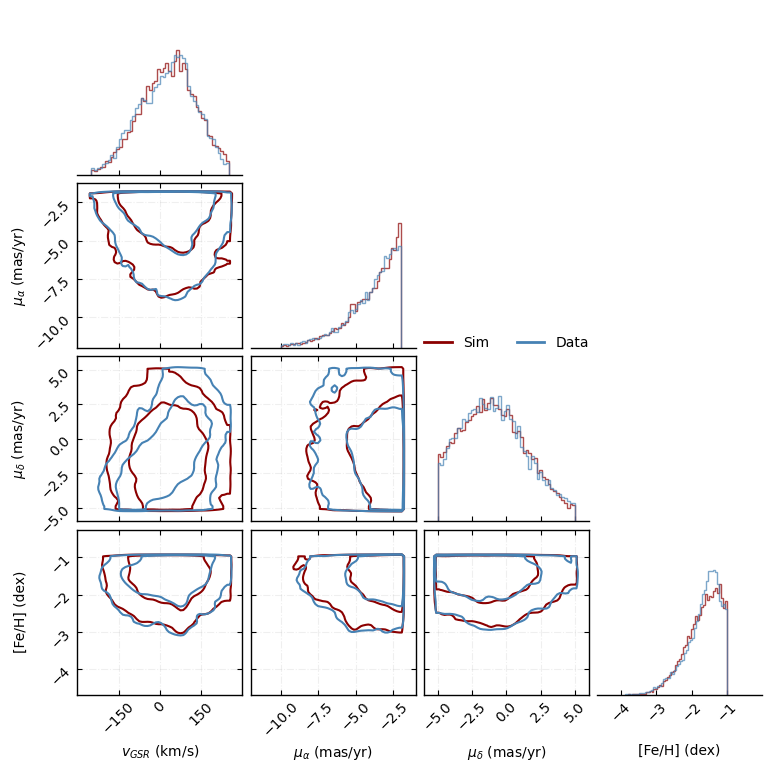

In [16]:
fig = corner.corner(
    sample_v[summary_keys],
    labels=summary_labels,
    color='darkred',
    smooth=1.5,
    bins=50,
    levels=[0.68, 0.95],
    plot_density=False,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "darkred", "histtype": "step", "alpha": 0.7},
)

corner.corner(
    stream_.all_memberships[summary_keys],
    labels=summary_labels,
    color='steelblue',
    smooth=1.5,
    bins=50,
    levels=[0.68, 0.95],
    plot_density=False,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "steelblue", "histtype": "step", "alpha": 0.7},
    fig=fig
)

fig.set_size_inches(2 * len(summary_labels), 2 * len(summary_labels))


axes_grid = np.array(fig.axes).reshape(len(summary_labels), len(summary_labels))

for ax in fig.axes:
    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    axis_scale_y = 1.2
    axies_scale_x = 1.2
    ax.set_ylim(ylim[0]*axis_scale_y, ylim[1]*axis_scale_y if ylim[1]>0 else ylim[1]+0.75)
    ax.set_xlim(xlim[0]*axies_scale_x, xlim[1]*axies_scale_x if xlim[1]>0 else xlim[1]+1)
    ax.tick_params(which="minor", color='1', length=0)

for i, ax in enumerate(np.diag(axes_grid)):

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1]*1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)

axes_grid[2,2].plot([], [], lw=2, c='darkred', label='Sim')
axes_grid[2,2].plot([], [], lw=2, c='steelblue', label='Data')
axes_grid[2,2].legend(frameon=False, bbox_to_anchor=(0.5, 1.2), loc='upper center', ncol=2);

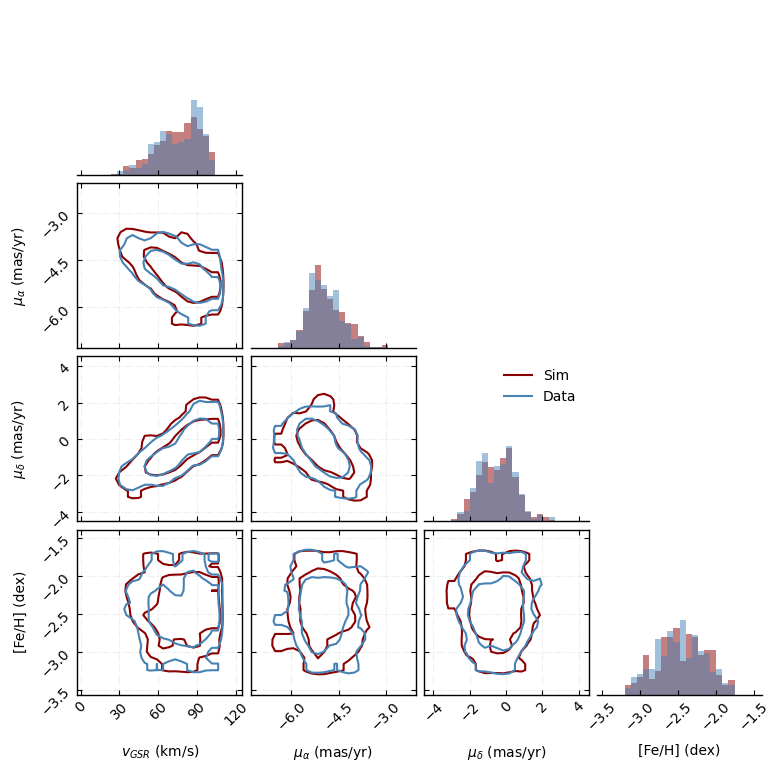

In [17]:
summary_keys = ['VGSR', 'PMRA', 'PMDEC', 'FEH']
summary_labels = [r'$v_{GSR}$ (km/s)', r'$\mu_{\alpha}$ (mas/yr)', r'$\mu_{\delta}$ (mas/yr)', r'[Fe/H] (dex)']
# plt.style.use('dark_background')

def catalogue_means(df):
    return np.array([np.nanmean(df[key]) for key in summary_keys])


_, samples_werr = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)
observed = stream_.stream_data.to_pandas()

sample_ = samples_werr

# Use contour-focused axis limits from central quantiles (shared by sim+data)
q_lo, q_hi = 0.01, 0.99
corner_ranges = []
for key in summary_keys:
    both = pd.concat([samples_werr[key], observed[key]], ignore_index=True).to_numpy()
    lo, hi = np.nanquantile(both, [q_lo, q_hi])
    corner_ranges.append((lo, hi))

fig = corner.corner(
    samples_werr[summary_keys],
    labels=summary_labels,
    color='darkred',
    smooth=1,
    bins=18,
    levels=[0.68, 0.95],
    range=corner_ranges,
    plot_density=False,
    plot_contours=True,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "darkred", "histtype": "stepfilled", "alpha": 0.5},
    data_kwargs={"ms": 2, "alpha": 0.5,
                 "mec": "darkred"},
)

corner.corner(
    observed[summary_keys],
    labels=summary_labels,
    color='steelblue',
    smooth=1,
    bins=18,
    levels=[0.68, 0.95],
    range=corner_ranges,
    plot_density=False,
    plot_contours=True,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "steelblue", "histtype": "stepfilled", "alpha": 0.5},
    data_kwargs={"ms": 2, "alpha": 0.5,
                 "mec": "steelblue"},
    fig=fig
)

fig.set_size_inches(2 * len(summary_labels), 2 * len(summary_labels))


axes_grid = np.array(fig.axes).reshape(len(summary_labels), len(summary_labels))

ndim = len(summary_keys)
padding_scale=1.5
for i, ax in enumerate(fig.axes):
    row = i // ndim
    col = i % ndim
    if row == col:  # skip diagonal
        plot_form(ax)
        xlim = ax.get_xlim()
        
        x_center = (xlim[0] + xlim[1]) / 2
        x_range = xlim[1] - xlim[0]
        
        new_x_range = x_range * padding_scale
        
        ax.set_xlim(x_center - new_x_range/2, x_center + new_x_range/2)
        
        ax.tick_params(which="minor", color='1', length=0)
        continue

    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    
    y_center = (ylim[0] + ylim[1]) / 2
    y_range = ylim[1] - ylim[0]
    x_center = (xlim[0] + xlim[1]) / 2
    x_range = xlim[1] - xlim[0]
    
    new_y_range = y_range * padding_scale
    new_x_range = x_range * padding_scale
    
    ax.set_ylim(y_center - new_y_range/2, y_center + new_y_range/2)
    ax.set_xlim(x_center - new_x_range/2, x_center + new_x_range/2)
    
    ax.tick_params(which="minor", color='1', length=0)

for ax in np.diag(axes_grid):
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1]*2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)
    

axes_grid[2,2].plot([], [], c='darkred', label='Sim')
axes_grid[2,2].plot([], [], c='steelblue', label='Data')
axes_grid[2,2].legend(frameon=False)



# Multiple Posterior Realizations

In [18]:
n_draws = 100
ppc_vals_all = None
phi1_index_all = None
ppc_list_all = []

import tqdm

for d in tqdm.tqdm(range(n_draws)):
    _, samples_werr = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)
    _, background_werr = draw_background(np.arange(14, 23), background_stars, 1, stream_.all_memberships)

    mock = pd.concat([samples_werr, background_werr], ignore_index=True)

    g = mock.groupby("phi1")[summary_keys].mean()  # 1 row per phi1 (if phi1 duplicates, this is the intended aggregation)

    if phi1_index_all is None:
        phi1_index_all = g.index
        ppc_vals_all = np.empty((n_draws, len(phi1_index_all), len(summary_keys)), dtype=float)

    g = g.reindex(phi1_index_all)  # keep consistent ordering
    ppc_list_all.append(g)
    ppc_vals_all[d] = g.to_numpy()

mean_all = ppc_vals_all.mean(axis=0)
q16_all, q84_all = np.quantile(ppc_vals_all, [0.16, 0.84], axis=0)
q025_all, q975_all = np.quantile(ppc_vals_all, [0.025, 0.975], axis=0)

_ci_all = pd.concat(
    {
        "mean":     pd.DataFrame(mean_all, index=phi1_index_all, columns=summary_keys),
        "ci_lower": pd.DataFrame(q16_all,  index=phi1_index_all, columns=summary_keys),
        "ci_upper": pd.DataFrame(q84_all,  index=phi1_index_all, columns=summary_keys),
    },
    axis=1,
)

_ci2_all = pd.concat(
    {
        "mean":     pd.DataFrame(mean_all,  index=phi1_index_all, columns=summary_keys),
        "ci_lower": pd.DataFrame(q025_all,  index=phi1_index_all, columns=summary_keys),
        "ci_upper": pd.DataFrame(q975_all,  index=phi1_index_all, columns=summary_keys),
    },
    axis=1,
)



100%|██████████| 100/100 [00:07<00:00, 12.77it/s]


Text(0.5, -0.02, 'Observed quantiles')

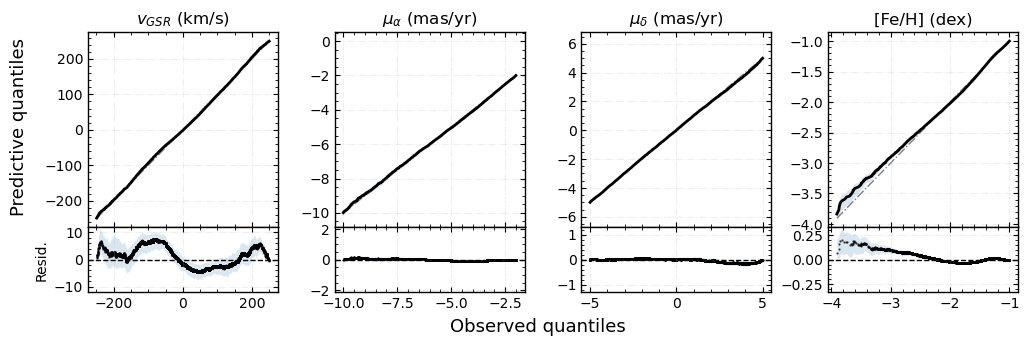

In [19]:
fig = plt.figure(figsize=(16*0.75, 4.5*0.75))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.0, wspace=0.3)

for idx in range(4):

    # --- Extract observed vector ---
    obs_vec = stream_.all_memberships[summary_keys[idx]].to_numpy()
    obs_sorted = np.sort(obs_vec)
    n_obs = len(obs_sorted)

    # Prepare Q-grid for interpolation (common quantile axis)
    q = np.linspace(0, 1, n_obs)

    # --- Compute predictive quantiles for each posterior draw ---
    ppc_q = []   # will be shape (n_draws, n_obs)

    for mock in ppc_list_all:
        x = mock[summary_keys[idx]].to_numpy()
        x_sorted = np.sort(x)

        # Interpolate predictive distribution to shared q-grid
        ppc_q.append(
            np.interp(q, np.linspace(0, 1, len(x_sorted)), x_sorted)
        )

    ppc_q = np.array(ppc_q)    # (n_draws, n_quantiles)

    # --- Bayesian predictive envelopes ---
    rep_sorted   = np.median(ppc_q, axis=0)
    lower_sorted = np.percentile(ppc_q, 16, axis=0)
    upper_sorted = np.percentile(ppc_q, 84, axis=0)

    lower_sorted2 = np.percentile(ppc_q, 2.5, axis=0)
    upper_sorted2 = np.percentile(ppc_q, 97.5, axis=0)

    # --- residuals ---
    residuals = rep_sorted - obs_sorted

    # --- plot structure preserved exactly as yours ---
    ax_qq = fig.add_subplot(gs[0, idx])
    ax_res = fig.add_subplot(gs[1, idx], sharex=ax_qq)

    # Q-Q line (median predictive)
    ax_qq.plot(obs_sorted, rep_sorted, c='k', lw=2)
    ax_qq.set_title(f'{summary_labels[idx]}')

    # Shaded PPC ribbons
    # ax_qq.fill_between(obs_sorted, lower_sorted, upper_sorted,
    #                    color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_qq.fill_between(obs_sorted, lower_sorted2, upper_sorted2,
                       color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # 1:1 line
    ax_qq.plot([obs_sorted[0], obs_sorted[-1]],
               [obs_sorted[0], obs_sorted[-1]],
               c='0.5', ls='-.', lw=1, zorder=0)

    ax_qq.tick_params(labelbottom=False)
    plot_form(ax_qq)

    # Residual plot
    ax_res.scatter(obs_sorted, residuals, c='k', s=0.5, alpha=0.6)
    ax_res.axhline(0, c='k', ls='--', lw=1)

    # ax_res.fill_between(obs_sorted, lower_sorted - obs_sorted,
    #                     upper_sorted - obs_sorted,
    #                     color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_res.fill_between(obs_sorted, lower_sorted2 - obs_sorted,
                        upper_sorted2 - obs_sorted,
                        color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # Center residual y-axis on 0
    ymin, ymax = ax_res.get_ylim()
    yabs = max(abs(ymin), abs(ymax))
    ax_res.set_ylim(-yabs, yabs)

    plot_form(ax_res)
    if idx == 0:
        ax_res.set_ylabel('Resid.', fontsize=10)

fig.supylabel('Predictive quantiles', x=0.06, y=0.6, fontsize=13)
fig.supxlabel('Observed quantiles', y=-0.02, fontsize=13)


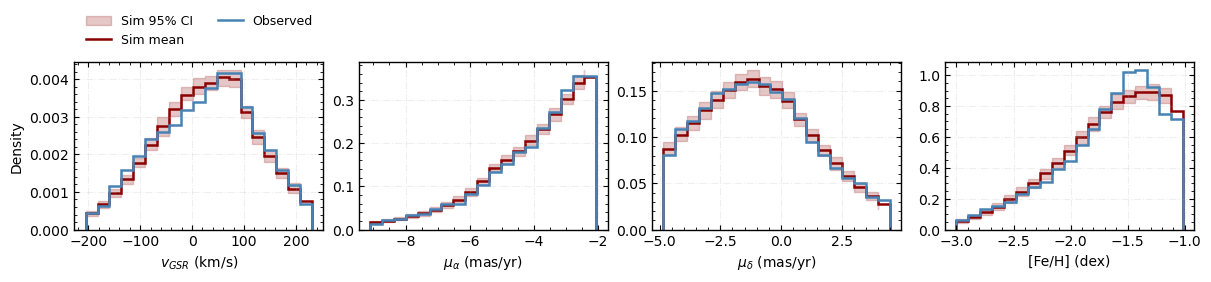

In [20]:
# PPC: 1D histograms with simulated 95% CI band
fig, axes = plt.subplots(1, len(summary_keys), figsize=(16*0.75, 3.6*0.75), constrained_layout=True)

for idx, key in enumerate(summary_keys):
    ax = axes[idx]

    # Observed values
    obs = stream_.all_memberships[key].to_numpy(dtype=float)

    # Simulated values from each posterior predictive draw
    sim_draws = [mock[key].to_numpy(dtype=float) for mock in ppc_list_all]

    # Shared binning using robust limits to avoid extreme outlier-driven axes
    all_vals = np.concatenate([obs] + sim_draws)
    lo, hi = np.nanquantile(all_vals, [0.01, 0.99])
    bins = np.linspace(lo, hi, 20)

    # Histogram for each simulated draw -> posterior predictive uncertainty per bin
    sim_hists = np.array([
        np.histogram(x, bins=bins, density=True)[0]
        for x in sim_draws
    ])

    sim_mean = np.nanmean(sim_hists, axis=0)
    sim_lo = np.nanpercentile(sim_hists, 2.5, axis=0)
    sim_hi = np.nanpercentile(sim_hists, 97.5, axis=0)

    # Observed histogram (same step representation as simulated summaries)
    obs_hist = np.histogram(obs, bins=bins, density=True)[0]

    # Simulated 95% CI band and mean
    ax.stairs(sim_hi, bins, color='none')
    ax.fill_between(
        bins[:-1], sim_lo, sim_hi, step='post', color='darkred', alpha=0.22, label='Sim 95% CI'
    )
    ax.stairs(sim_mean, bins, color='darkred', lw=1.8, label='Sim mean')

    # Observed step curve
    ax.stairs(obs_hist, bins, color='steelblue', lw=1.8, label='Observed')

    ax.set_xlabel(summary_labels[idx])
    if idx == 0:
        ax.set_ylabel('Density')
    plot_form(ax)

axes[0].legend(frameon=False, fontsize=9, bbox_to_anchor=(0, 1.35), loc='upper left', ncol=2)




## Stream Only

In [21]:
n_draws = 100
ppc_vals_stream = None
phi1_index_stream = None
ppc_list_stream = []

import tqdm

for d in tqdm.tqdm(range(n_draws)):
    _, mock = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)

    g = mock.groupby("phi1")[summary_keys].mean()  # 1 row per phi1 (if phi1 duplicates, this is the intended aggregation)

    if phi1_index_stream is None:
        phi1_index_stream = g.index
        ppc_vals_stream = np.empty((n_draws, len(phi1_index_stream), len(summary_keys)), dtype=float)

    g = g.reindex(phi1_index_stream)  # keep consistent ordering
    ppc_list_stream.append(g)
    ppc_vals_stream[d] = g.to_numpy()

mean_stream = ppc_vals_stream.mean(axis=0)
q16_stream, q84_stream = np.quantile(ppc_vals_stream, [0.16, 0.84], axis=0)
q025_stream, q975_stream = np.quantile(ppc_vals_stream, [0.025, 0.975], axis=0)

_ci_stream = pd.concat(
    {
        "mean":     pd.DataFrame(mean_stream, index=phi1_index_stream, columns=summary_keys),
        "ci_lower": pd.DataFrame(q16_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_upper": pd.DataFrame(q84_stream,  index=phi1_index_stream, columns=summary_keys),
    },
    axis=1,
)

_ci2_stream = pd.concat(
    {
        "mean":     pd.DataFrame(mean_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_lower": pd.DataFrame(q025_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_upper": pd.DataFrame(q975_stream,  index=phi1_index_stream, columns=summary_keys),
    },
    axis=1,
)



100%|██████████| 100/100 [00:06<00:00, 15.71it/s]


Text(0.5, -0.02, 'Observed quantiles')

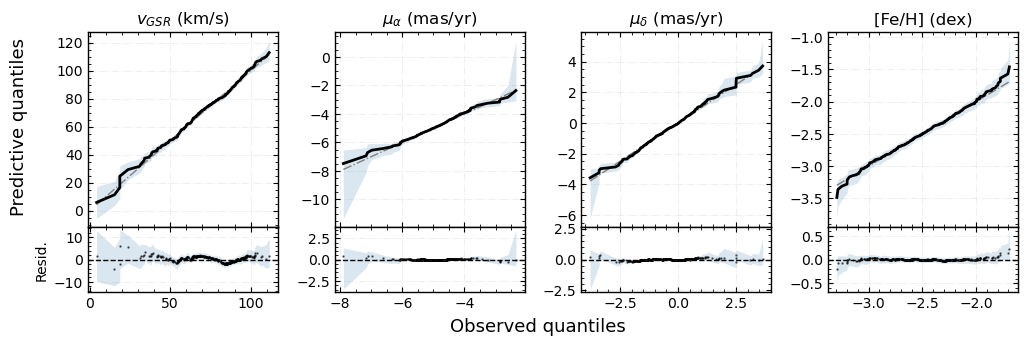

In [22]:
fig = plt.figure(figsize=(16*0.75, 4.5*0.75))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.0, wspace=0.3)

for idx in range(4):

    # --- Extract observed vector ---
    obs_vec = stream_.stream_data[summary_keys[idx]]
    obs_sorted = np.sort(obs_vec)
    n_obs = len(obs_sorted)

    # Prepare Q-grid for interpolation (common quantile axis)
    q = np.linspace(0, 1, n_obs)

    # --- Compute predictive quantiles for each posterior draw ---
    ppc_q = []   # will be shape (n_draws, n_obs)

    for mock in ppc_list_stream:
        x = mock[summary_keys[idx]].to_numpy()
        x_sorted = np.sort(x)

        # Interpolate predictive distribution to shared q-grid
        ppc_q.append(
            np.interp(q, np.linspace(0, 1, len(x_sorted)), x_sorted)
        )

    ppc_q = np.array(ppc_q)    # (n_draws, n_quantiles)

    # --- Bayesian predictive envelopes ---
    rep_sorted   = np.median(ppc_q, axis=0)
    lower_sorted = np.percentile(ppc_q, 16, axis=0)
    upper_sorted = np.percentile(ppc_q, 84, axis=0)

    lower_sorted2 = np.percentile(ppc_q, 2.5, axis=0)
    upper_sorted2 = np.percentile(ppc_q, 97.5, axis=0)

    # --- residuals ---
    residuals = rep_sorted - obs_sorted

    # --- plot structure preserved exactly as yours ---
    ax_qq = fig.add_subplot(gs[0, idx])
    ax_res = fig.add_subplot(gs[1, idx], sharex=ax_qq)

    # Q-Q line (median predictive)
    ax_qq.plot(obs_sorted, rep_sorted, c='k', lw=2)
    ax_qq.set_title(f'{summary_labels[idx]}')

    # Shaded PPC ribbons
    # ax_qq.fill_between(obs_sorted, lower_sorted, upper_sorted,
    #                    color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_qq.fill_between(obs_sorted, lower_sorted2, upper_sorted2,
                       color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # 1:1 line
    ax_qq.plot([obs_sorted[0], obs_sorted[-1]],
               [obs_sorted[0], obs_sorted[-1]],
               c='0.5', ls='-.', lw=1, zorder=0)

    ax_qq.tick_params(labelbottom=False)
    plot_form(ax_qq)

    # Residual plot
    ax_res.scatter(obs_sorted, residuals, c='k', s=0.5, alpha=0.6)
    ax_res.axhline(0, c='k', ls='--', lw=1)

    # ax_res.fill_between(obs_sorted, lower_sorted - obs_sorted,
    #                     upper_sorted - obs_sorted,
    #                     color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_res.fill_between(obs_sorted, lower_sorted2 - obs_sorted,
                        upper_sorted2 - obs_sorted,
                        color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # Center residual y-axis on 0
    ymin, ymax = ax_res.get_ylim()
    yabs = max(abs(ymin), abs(ymax))
    ax_res.set_ylim(-yabs, yabs)

    plot_form(ax_res)
    if idx == 0:
        ax_res.set_ylabel('Resid.', fontsize=10)

fig.supylabel('Predictive quantiles', x=0.06, y=0.6, fontsize=13)
fig.supxlabel('Observed quantiles', y=-0.02, fontsize=13)


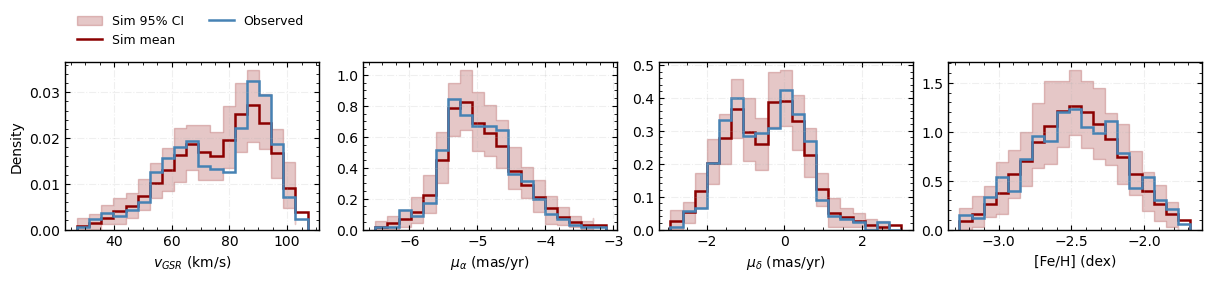

In [23]:
# PPC: 1D histograms with simulated 95% CI band
fig, axes = plt.subplots(1, len(summary_keys), figsize=(16*0.75, 3.6*0.75), constrained_layout=True)

for idx, key in enumerate(summary_keys):
    ax = axes[idx]

    # Observed values
    obs = stream_.stream_data[key]

    # Simulated values from each posterior predictive draw
    sim_draws = [mock[key].to_numpy(dtype=float) for mock in ppc_list_stream]

    # Shared binning using robust limits to avoid extreme outlier-driven axes
    all_vals = np.concatenate([obs] + sim_draws)
    lo, hi = np.nanquantile(all_vals, [0.01, 0.99])
    bins = np.linspace(lo, hi, 20)

    # Histogram for each simulated draw -> posterior predictive uncertainty per bin
    sim_hists = np.array([
        np.histogram(x, bins=bins, density=True)[0]
        for x in sim_draws
    ])

    sim_mean = np.nanmean(sim_hists, axis=0)
    sim_lo = np.nanpercentile(sim_hists, 2.5, axis=0)
    sim_hi = np.nanpercentile(sim_hists, 97.5, axis=0)

    # Observed histogram (same step representation as simulated summaries)
    obs_hist = np.histogram(obs, bins=bins, density=True)[0]

    # Simulated 95% CI band and mean
    ax.stairs(sim_hi, bins, color='none')
    ax.fill_between(
        bins[:-1], sim_lo, sim_hi, step='post', color='darkred', alpha=0.22, label='Sim 95% CI'
    )
    ax.stairs(sim_mean, bins, color='darkred', lw=1.8, label='Sim mean')

    # Observed step curve
    ax.stairs(obs_hist, bins, color='steelblue', lw=1.8, label='Observed')

    ax.set_xlabel(summary_labels[idx])
    if idx == 0:
        ax.set_ylabel('Density')
    plot_form(ax)

axes[0].legend(frameon=False, fontsize=9, bbox_to_anchor=(0, 1.35), loc='upper left', ncol=2)




# Background

Applying box cuts...
Not applying BHB cut
Box cuts applied. Access total masks using StreamMembers.<handler>.sel
Plotting box cuts...


(-4.25, -1.0)

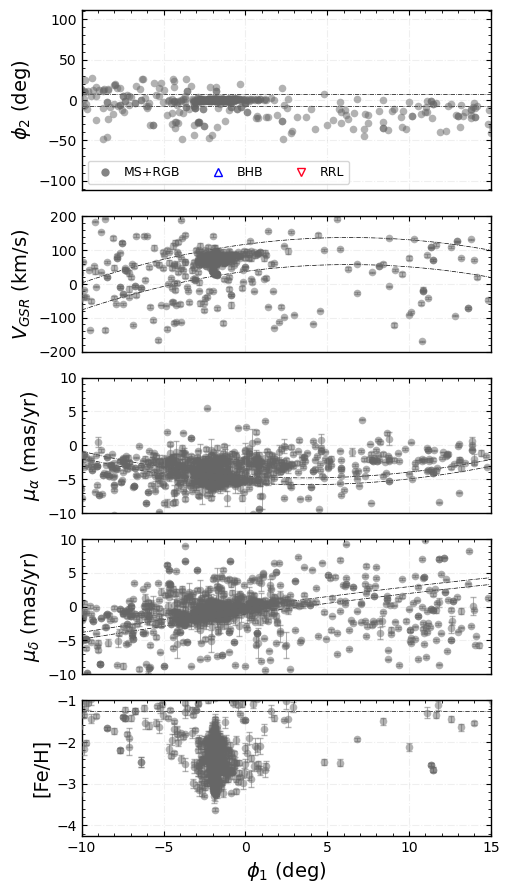

In [40]:
fig, ax = stream_.box_cut(pad=np.array([40., -1.25, 0.5, 0.5, 7.]), # vgsr, feh, pmra, pmdec, phi2
            withIso=True,    # keep the isochrone filter on
            withAss=False, residual=False, 
            show_panels=[0, 1,2,3,4])  

ax[1].set_ylim(-200, 200)
ax[2].set_ylim(-10, 10)
ax[3].set_ylim(-10, 10)
ax[4].set_ylim(-4.25, -1.)

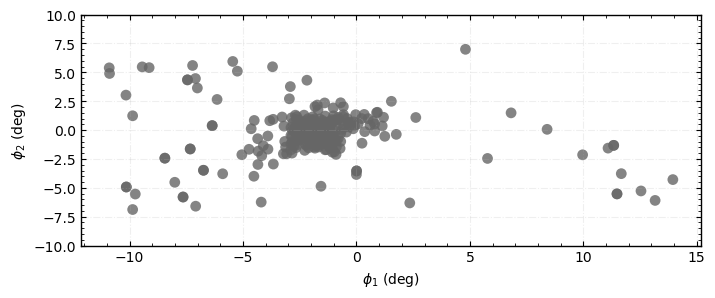

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.scatter(stream_.ms_handler.data[stream_.ms_handler.sel]['phi1'], stream_.ms_handler.data[stream_.ms_handler.sel]['phi2'], s=60, edgecolors='none', facecolors='0.4', alpha=0.8)
ax.set_ylabel(r'$\phi_2$ (deg)')
ax.set_xlabel(r'$\phi_1$ (deg)')
ax.set_ylim(-10, 10)
plot_form(ax)

No orbit results found, skipping orbit track plotting
/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/libraries/post_mcmc.py:2696: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



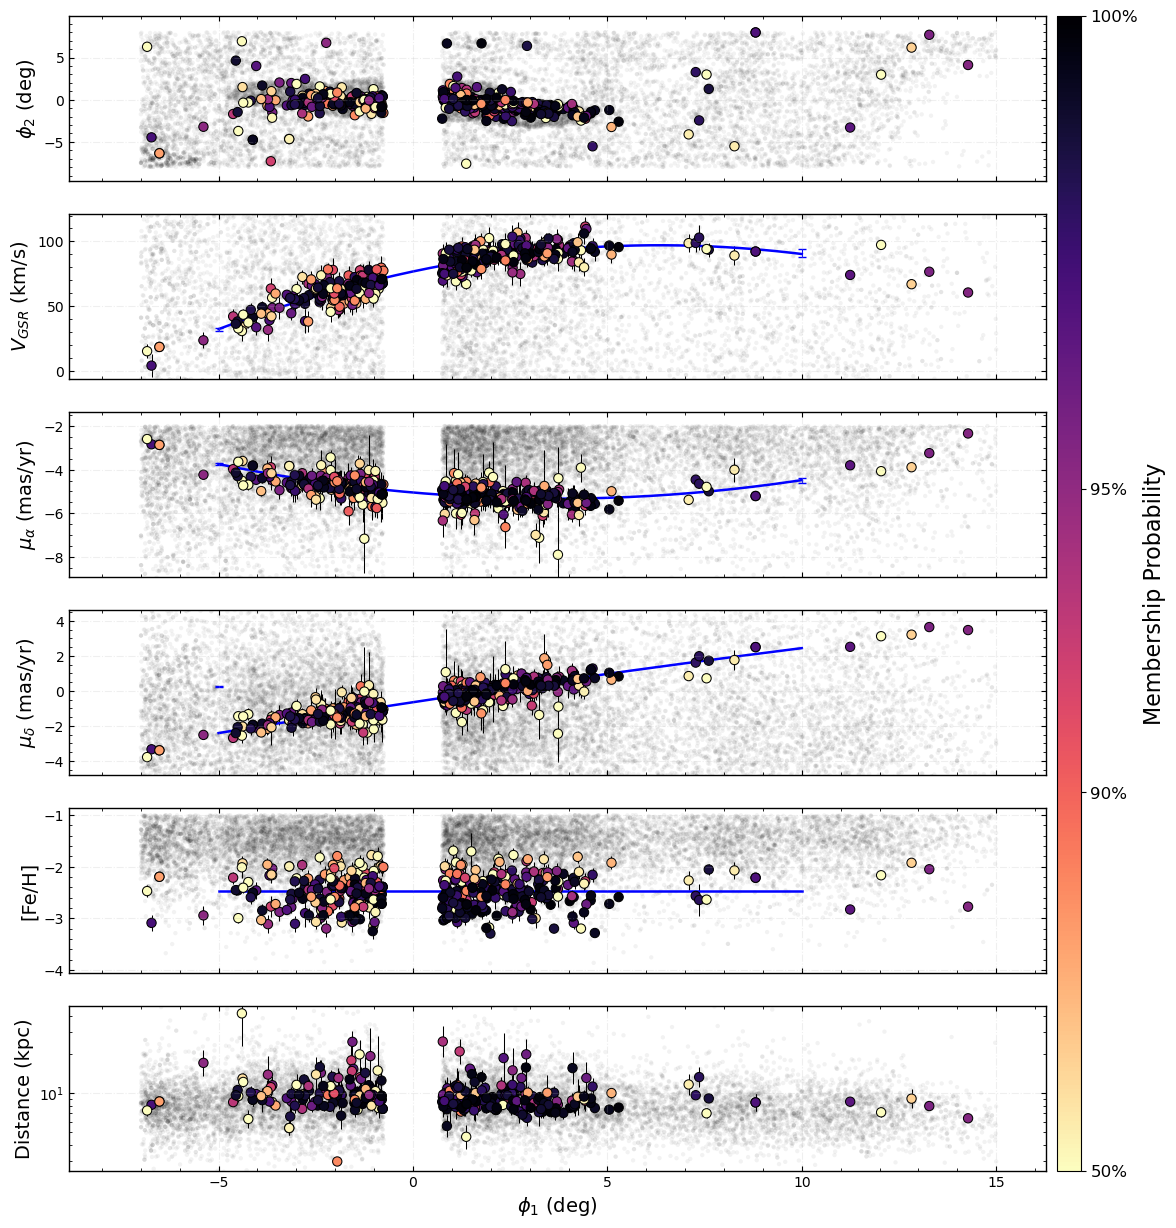